## CSCI-4041 - Algorithms - Chapter 7 - Quick Sort

### Joy Upton Azzam

### 2/7/2026

<mark>_____________________________________________________________________________________</mark>

### 1. QuickSort Algorithm


<div style="width:75%; margin: auto;">

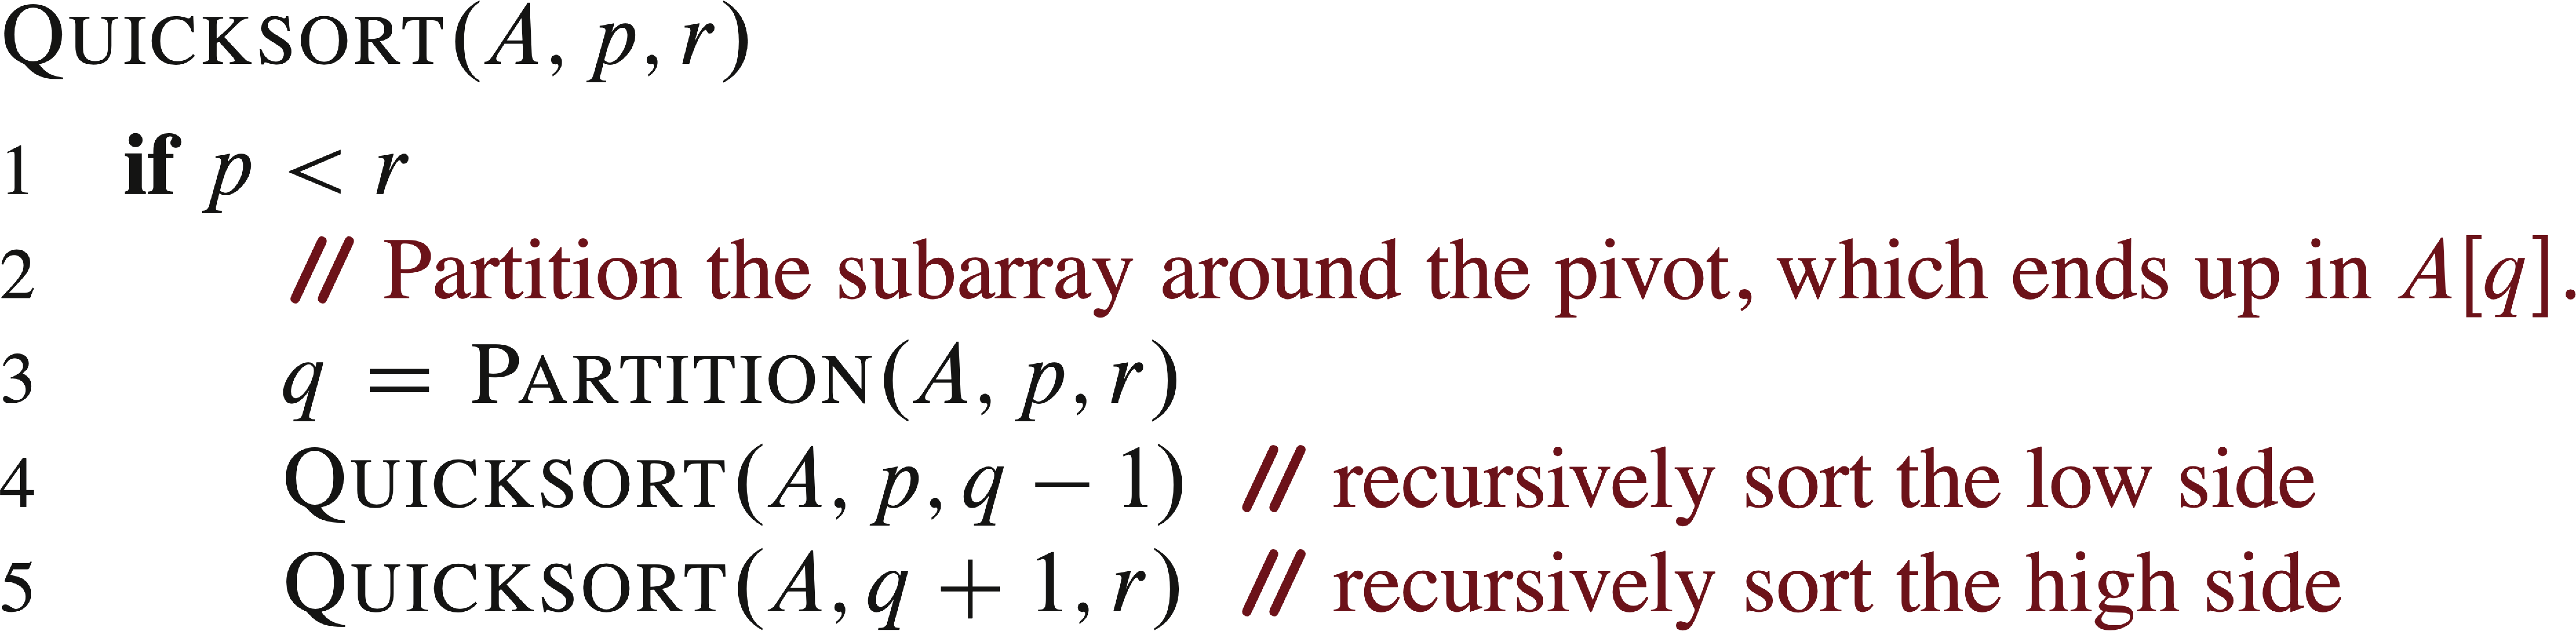

</div>

which relies on the ```Partition``` method below which performs the division of the data to work on.

<div style="width:75%; margin: auto;">

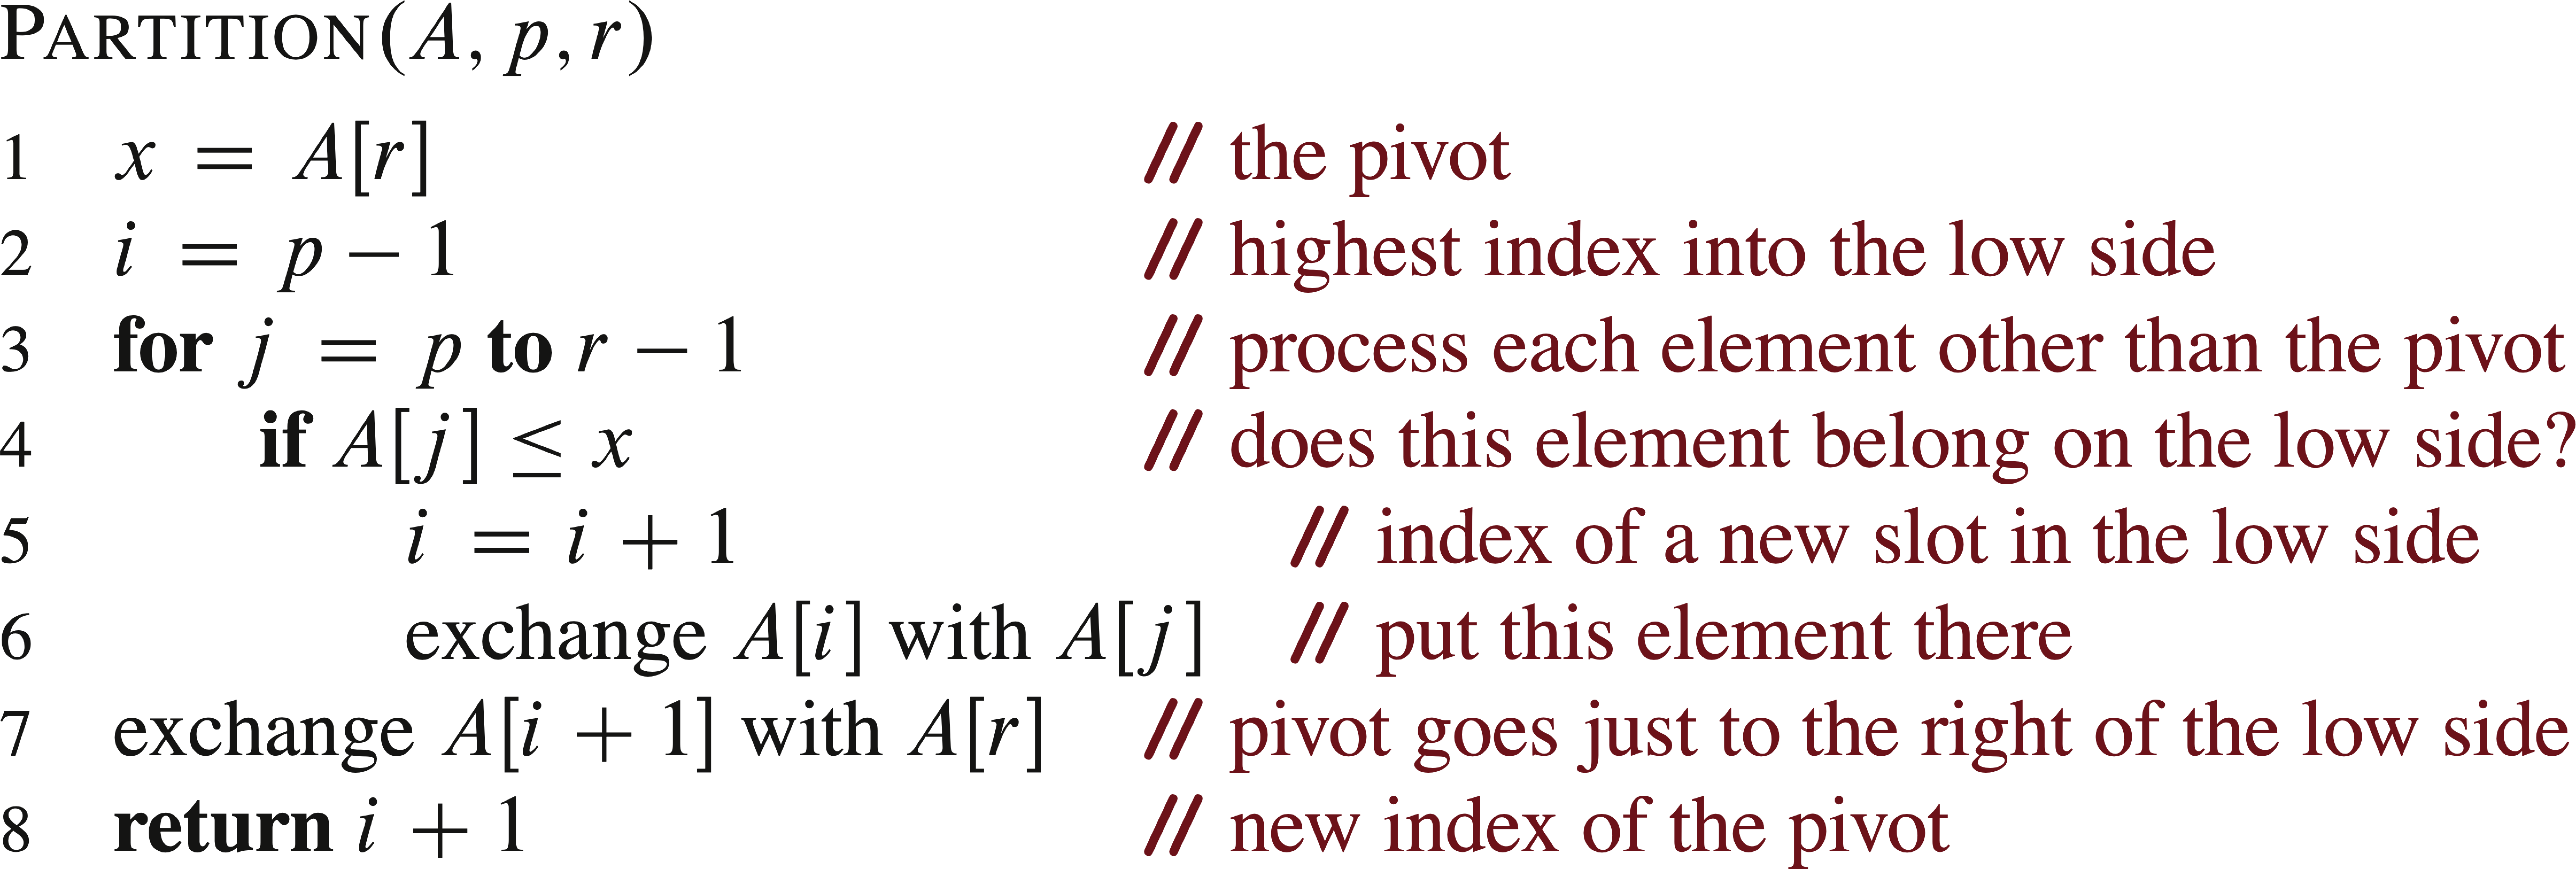

</div>


In [91]:
def Quicksort(A,p,r):
    """Quicksort procedure from chapter 7 - CLRS"""
        
    if p < r:
        
        ######################################## divide
        q = Partition(A,p,r)
        
        ######################################## conquer
        Quicksort(A,p,q-1)
        Quicksort(A,q+1,r)

        ######################################## combine

In [93]:
def Partition(A,p,r):
    """Partition procedure from chapter 7 - CLRS"""

    x = A[r]
    i = p - 1
    for j in range(p,r):
        if A[j] <= x:              # check for larger values to move right
            i = i + 1              # next fill location
            A[i],A[j] = A[j],A[i]  # swap
    
    # place pivot in center location
    i=i+1
    A[i],A[r] = A[r],A[i]      # swap pivot element
    return i                   # return pivot location

In [95]:
A = [5,4,3,2,1]
print("before:",A)

# Call Method
Quicksort(A,0,4)
print("after:",A)

before: [5, 4, 3, 2, 1]
after: [1, 2, 3, 4, 5]


<mark>_____________________________________________________________________________________</mark>

### 2. Testing Correctness for larger (random) arrays

In the sub-sections (a), (b), and (c) which follow, I test the standard ```Quicksort``` method on 3 different types of inputs.

1. Random Data
    * this is used to understand something like the "average" case -since average data would look random
2. Constant Data
    * this may not seem typical, but for large arrays, some sub-array may be constant which ```Quicksort``` recurses to.
3. Decreasing Data
    * again, this may seem arbitrary, but for large arrays, some sub-array may be decreasing.
  
As we will see in lecture, homework, and numerical experiment, the last two are a sort of "worst-case" for the algorithm which needs to be handled for a robust sorting method.

In [107]:
def sameQ(A,B):
    """returns True if arrays A and B contain the same values"""
    
    m,n = len(A),len(B)     # compute lengths
    if m!=n: return False   # check if length is the same
    
    for i in range(n):      # loop over elements
        if A[i]!=B[i]: return False # check if they are the same
    
    return True

#### (a) Random Data (~ Average Case)

In [149]:
from time import time
import random

total_time = 0
runs = 20

for i in range(runs):
    
    n = 2000
    N = n*n
    A = [random.randrange(-N,N) for i in range(n)]
    correct_sort = sorted(A)
    
    ################ merge sort sort ##############
    start = time()
    Quicksort(A,0,n-1)
    stop = time()
    total_time += stop - start
    if not sameQ(A,correct_sort):
        print("incorrect .... :(")
    
print("Average time for QuickSort (CLRS):",total_time/runs)

Average time for QuickSort (CLRS): 0.004996383190155029


#### (b) Constant Data (Worst Case)

In [173]:
from time import time
import random

total_time = 0
runs = 20

n = 2000
A = [1 for i in range(n)]
correct_sort = sorted(A)


for i in range(runs):
        
    ################ merge sort sort ##############
    start = time()
    Quicksort(A,0,n-1)
    stop = time()
    total_time += stop - start
    if not sameQ(A,correct_sort):
        print("incorrect .... :(")
    
print("Average time for QuickSort (CLRS):",total_time/runs)

Average time for QuickSort (CLRS): 0.4465330243110657


#### (c) Reverse Data (Worst Case)

In [175]:
from time import time
import random

total_time = 0
runs = 20

n = 2000
A = [i for i in range(n)]
A = list(reversed(A))
correct_sort = sorted(A)


for i in range(runs):
        
    ################ merge sort sort ##############
    start = time()
    Quicksort(A,0,n-1)
    stop = time()
    total_time += stop - start
    if not sameQ(A,correct_sort):
        print("incorrect .... :(")
    A = list(reversed(A))
    
print("Average time for QuickSort (CLRS):",total_time/runs)

Average time for QuickSort (CLRS): 0.2951736092567444


**Notes and Comments**

* The random case is very fast.
* The constant case is very slow. Why?
* The decreasing case is not quite as slow, but much work than typical (random). Why?

<mark>_____________________________________________________________________________________</mark>

### 3. Randomized QuickSort Algorithm

For a randomized variant, we can implement the comments in the CLRS text on page 192.

<div style="width:75%; margin: auto;">

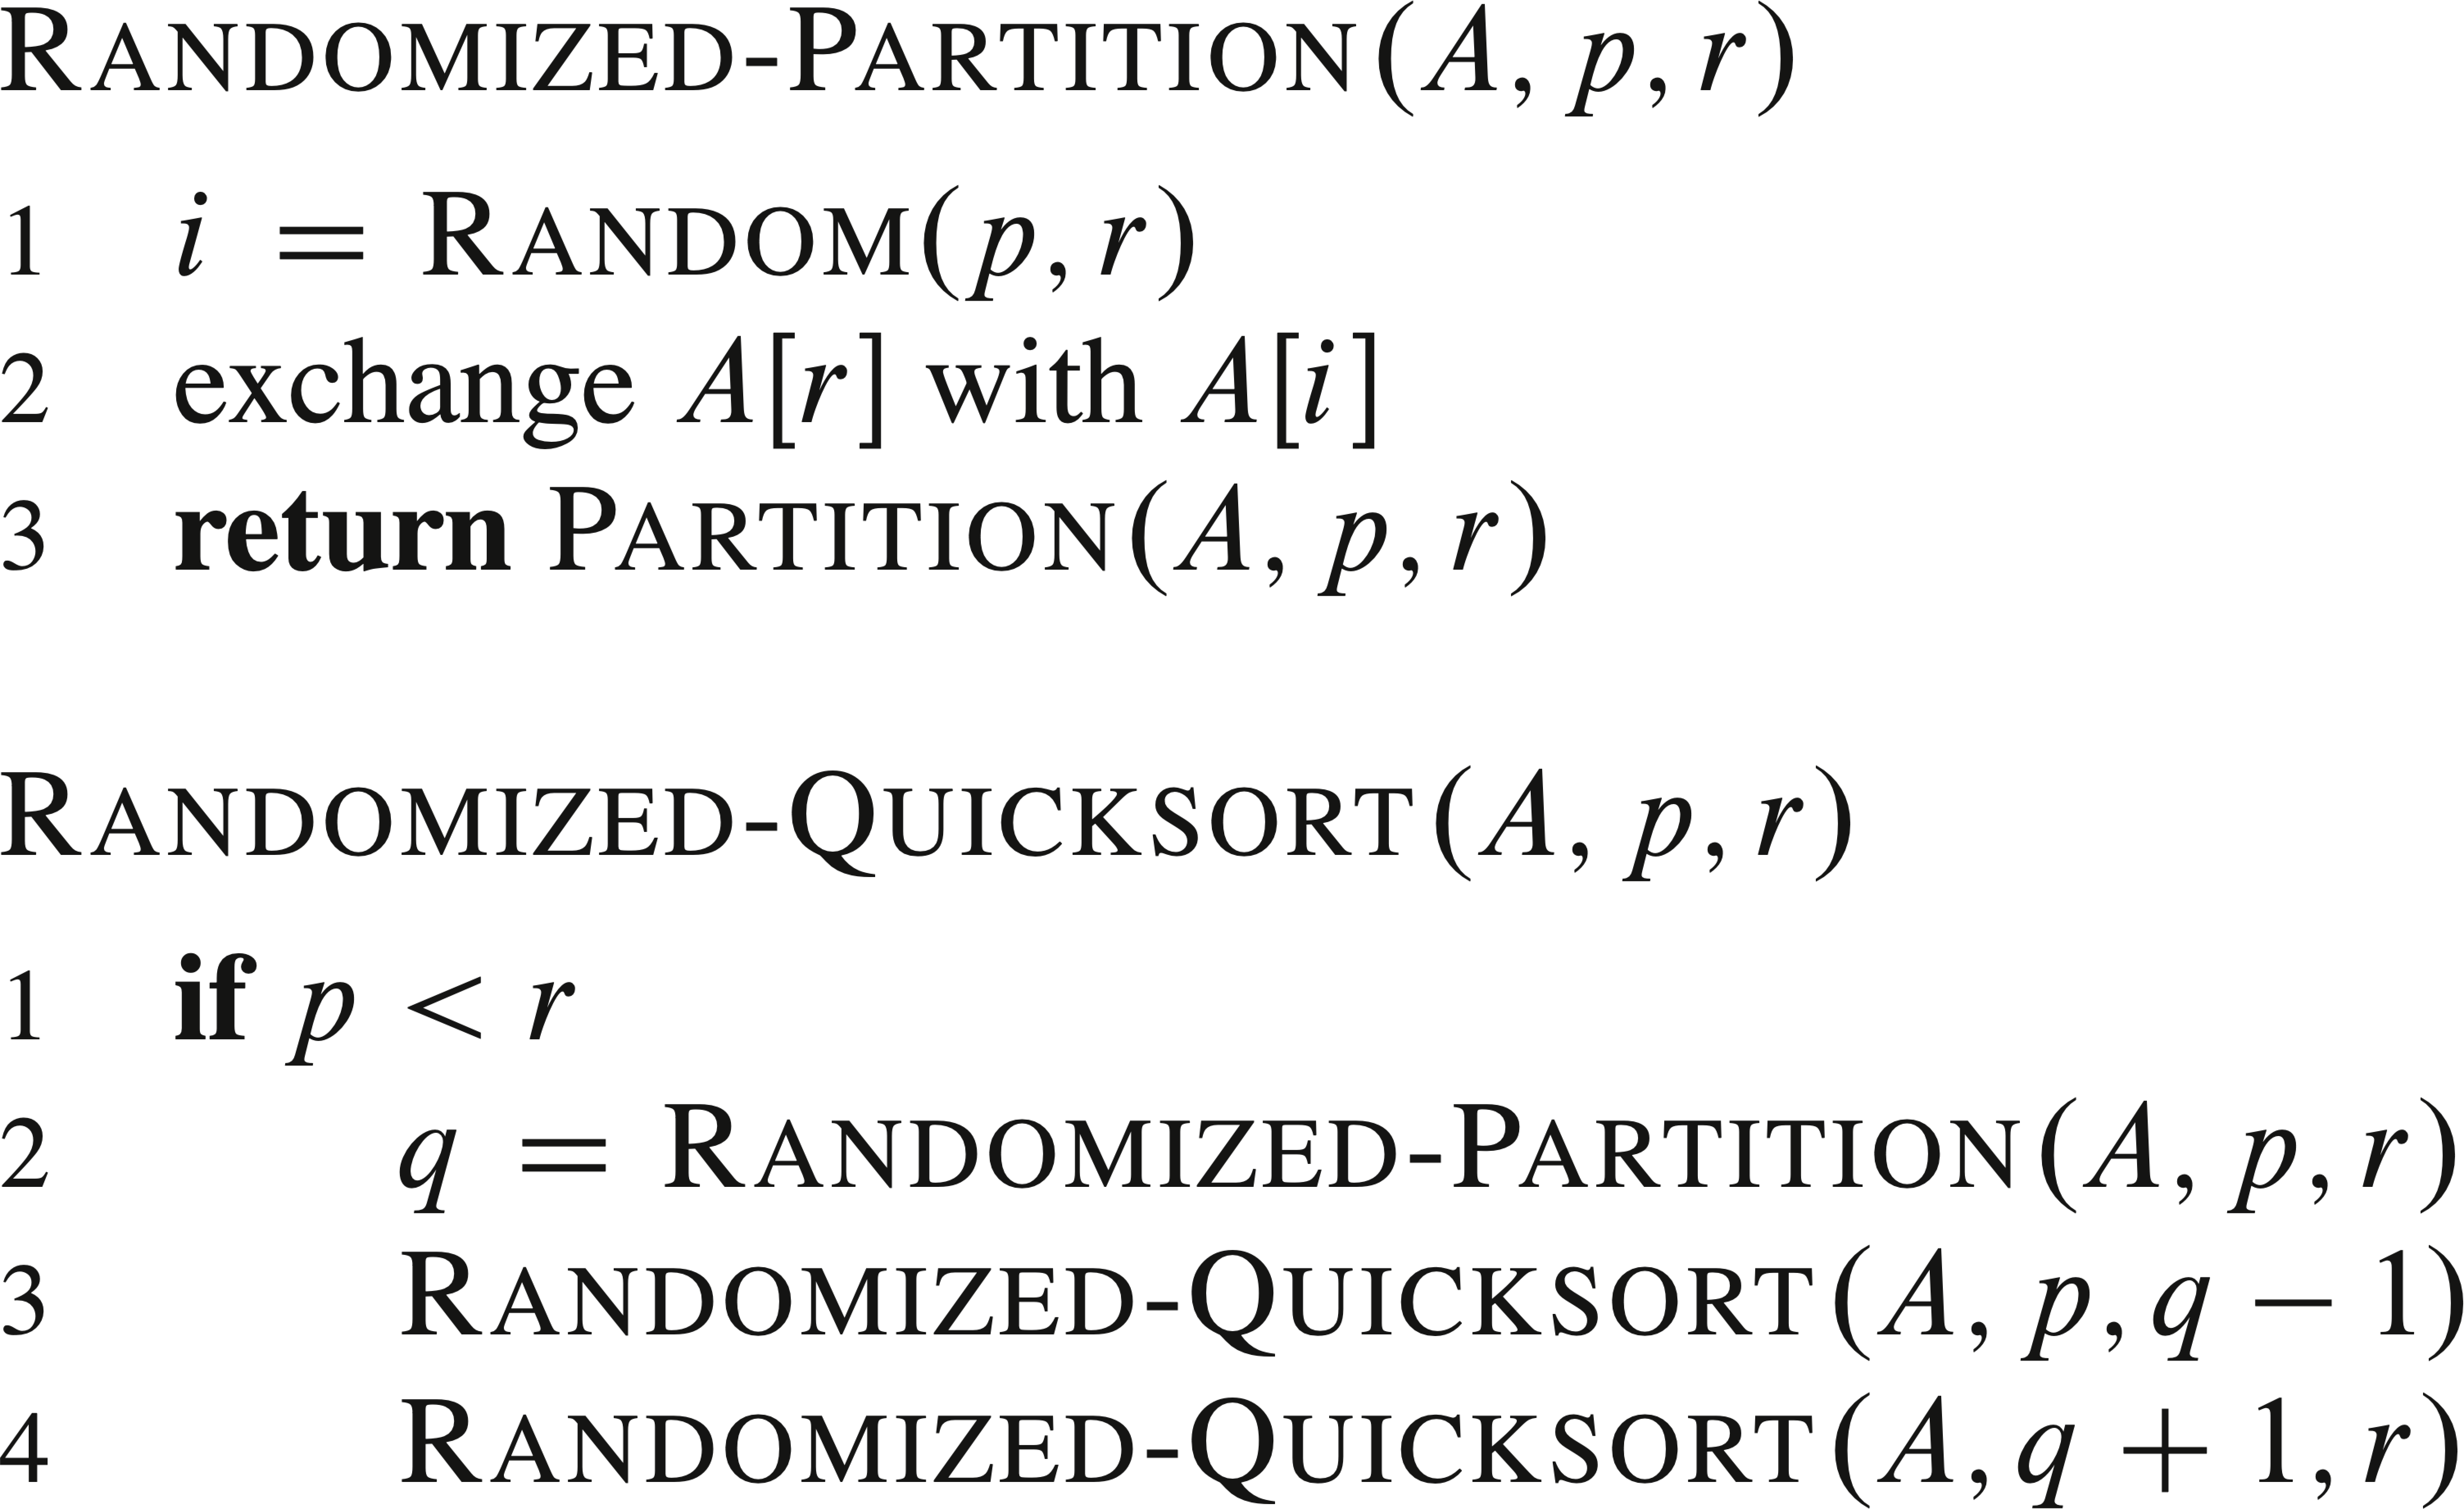

</div>

In [154]:
def Randomized_Quicksort(A,p,r):
    """Randomized Quicksort procedure from chapter 7 - CLRS"""
        
    if p < r:
        
        ######################################## divide
        q = Randomized_Partition(A,p,r)
        
        ######################################## conquer
        Randomized_Quicksort(A,p,q-1)
        Randomized_Quicksort(A,q+1,r)

        ######################################## combine

In [156]:
import random

def Randomized_Partition(A,p,r):
    """Randomized Partition procedure from chapter 7 - CLRS"""
    i = random.randrange(p,r+1)
    A[r],A[i] = A[i],A[r]
    return Partition(A,p,r)

In [158]:
A = [5,4,3,2,1]
print("before:",A)

# Call Method
Randomized_Quicksort(A,0,4)
print("after:",A)

before: [5, 4, 3, 2, 1]
after: [1, 2, 3, 4, 5]


<mark>_____________________________________________________________________________________</mark>

### 2. Testing Correctness for larger (random) arrays

#### (a) Random Data (~ Average Case)

In [162]:
from time import time
import random

total_time = 0
runs = 20

for i in range(runs):
    
    n = 2000
    N = n*n
    A = [random.randrange(-N,N) for i in range(n)]
    correct_sort = sorted(A)
    
    ################ merge sort sort ##############
    start = time()
    Randomized_Quicksort(A,0,n-1)
    stop = time()
    total_time += stop - start
    if not sameQ(A,correct_sort):
        print("incorrect .... :(")
    
print("Average time for QuickSort (CLRS):",total_time/runs)

Average time for QuickSort (CLRS): 0.006774318218231201


#### (b) Constant Data (Worst Case)

In [164]:
from time import time
import random

total_time = 0
runs = 20

n = 2000
A = [1 for i in range(n)]
correct_sort = sorted(A)


for i in range(runs):
        
    ################ merge sort sort ##############
    start = time()
    Randomized_Quicksort(A,0,n-1)
    stop = time()
    total_time += stop - start
    if not sameQ(A,correct_sort):
        print("incorrect .... :(")
    
print("Average time for QuickSort (CLRS):",total_time/runs)

Average time for QuickSort (CLRS): 0.44579514265060427


#### (c) Reverse Data (Worst Case)

In [169]:
from time import time
import random

total_time = 0
runs = 20

n = 2000
A = [i for i in range(n)]
A = list(reversed(A))
correct_sort = sorted(A)


for i in range(runs):
        
    ################ merge sort sort ##############
    start = time()
    Randomized_Quicksort(A,0,n-1)
    stop = time()
    total_time += stop - start
    if not sameQ(A,correct_sort):
        print("incorrect .... :(")
    A = list(reversed(A))
    
print("Average time for QuickSort (CLRS):",total_time/runs)

Average time for QuickSort (CLRS): 0.008653736114501953


**Notes and Comments**

* Randomization did not affect the fastest (random data -average) case.
* The constant data test is unchanged as the randomization cannot change the fact that they are all constant.
* By randomizing the indices before we ```Partition``` the array into two halves, we can elliminate the worst case for decreasing data.